In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/euclidean_distances.csv')
df1['Condition'] = 'Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/euclidean_distances.csv')
df2['Condition'] = 'Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/euclidean_distances.csv')
df3['Condition'] = 'Starved-Starved'


df = pd.concat([df1, df2, df3], ignore_index=True)

df = df[df['time'] <= 600]  # Filter to first 10 minutes


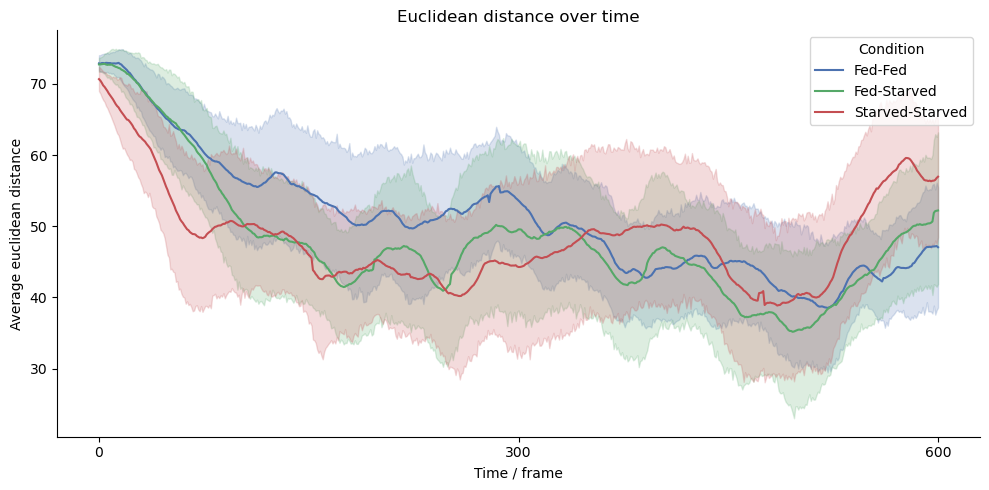

In [2]:
# average distance trace over time

distance_summary = df.groupby(['Condition', 'file', 'time']).agg(
    average_distance=('average_distance', 'mean'),
).reset_index()


palette = {
    'Fed-Fed': '#4C72B0',
    'Fed-Starved': '#55A868',
    'Starved-Starved': '#C44E52',
}

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=distance_summary,
    x='time',
    y='average_distance',
    hue='Condition',
    palette=palette,
    errorbar=('ci', 95),
    ax=ax,
)

tick_start = int(np.floor(distance_summary['time'].min() / 300) * 300)
tick_end = int(np.ceil(distance_summary['time'].max() / 300) * 300)
ax.set_xticks(np.arange(tick_start, tick_end + 300, 300))
ax.set_ylabel('Average euclidean distance')
ax.set_xlabel('Time / frame')
ax.set_title('Euclidean distance over time')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/euclidean-distance.pdf', format='pdf')
plt.show()
